In [1]:
# Cell 1 - Load and validate the primary LLE dataset
import importlib
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

# Optional pandas backends are not required here.
for optional_backend in ("pyarrow", "numexpr", "bottleneck"):
    sys.modules[optional_backend] = None
pd = importlib.import_module("pandas")


def find_phase1_dir(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src/chaos/lyapunov.py").is_file():
            return candidate
        nested = candidate / "phase1"
        if (nested / "src/chaos/lyapunov.py").is_file():
            return nested
    raise FileNotFoundError("Could not locate the phase1 directory.")


def require(condition: bool, message: str) -> None:
    """Raise a clear integrity error."""
    if not condition:
        raise ValueError(message)


def resolve_column(
    columns: set[str],
    aliases: tuple[str, ...],
    logical_name: str,
    required: bool = True,
) -> str | None:
    """Resolve one logical field from schema aliases."""
    matches = [alias for alias in aliases if alias in columns]
    require(
        len(matches) <= 1,
        f"Ambiguous columns for {logical_name}: {matches}",
    )
    if matches:
        return matches[0]
    if required:
        raise ValueError(f"Missing required field: {logical_name}")
    return None


def parse_boolean(series: pd.Series) -> pd.Series:
    """Parse a strict Boolean result column."""
    values = series.astype(str).str.strip().str.casefold()
    truthy = {"true", "1", "1.0", "yes", "pass", "included"}
    falsy = {"false", "0", "0.0", "no", "fail", "excluded"}
    require(
        values.isin(truthy | falsy).all(),
        f"Unsupported Boolean values in {series.name}.",
    )
    return values.isin(truthy)


PHASE1_DIR = find_phase1_dir(Path.cwd())
RESULT_DIR = PHASE1_DIR / "results" / "lle" / "processed"
OUTPUT_DIR = PHASE1_DIR / "outputs" / "lle"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPRESENTATION = "processed"
WINDOW_SIZE_S = 60
STATES = ("Awake", "Drowsy")
EXPECTED_SESSIONS = 20
EMBEDDING_DIMENSION = 8
TAU_SECONDS = 0.16
FIT_START_SECONDS = 0.80
FIT_END_SECONDS = 1.30
PRIMARY_R2_THRESHOLD = 0.90
SENSITIVITY_R2_THRESHOLD = 0.95

COLUMN_ALIASES = {
    "session": ("session", "session_id"),
    "state": ("state", "condition"),
    "window_size_s": ("window_size_s", "window_size"),
    "window_id": ("window_id", "window"),
    "representation": ("representation", "signal_representation"),
    "lle_1_per_s": ("lle_1_per_s", "lle", "LLE"),
    "fit_r2": ("fit_r2", "r2", "fit_R2"),
    "n_pairs_fit_min": ("n_pairs_fit_min", "n_pairs", "pair_support"),
    "n_pairs_initial": ("n_pairs_initial", "initial_pairs"),
    "theiler_s": ("theiler_s", "theiler_time_s", "theiler_time"),
    "fit_start_s": ("fit_start_s", "fit_start"),
    "fit_end_s": ("fit_end_s", "fit_end"),
    "analysis_included": ("analysis_included", "included", "include"),
    "signal_finite": ("signal_finite", "finite_signal"),
    "valid": ("valid", "qc_valid", "is_valid"),
    "qc_reason": ("qc_reason", "failure_reason", "invalid_reason"),
    "m": ("m", "embedding_dimension"),
    "tau_s": ("tau_s", "delay_s"),
    "follow_time_s": ("follow_time_s", "time_s", "divergence_time_s"),
    "mean_log_divergence": (
        "mean_log_divergence",
        "mean_log_distance",
        "log_divergence",
    ),
}
OPTIONAL_FIELDS = {
    "n_pairs_initial",
    "analysis_included",
    "signal_finite",
    "valid",
    "qc_reason",
    "follow_time_s",
    "mean_log_divergence",
}

result_paths = sorted(RESULT_DIR.glob("*.csv"))
require(
    len(result_paths) == EXPECTED_SESSIONS,
    f"Expected {EXPECTED_SESSIONS} result files; found {len(result_paths)}.",
)
headers = [set(pd.read_csv(path, nrows=0).columns) for path in result_paths]
common_columns = set.intersection(*headers)
schema = {
    logical_name: resolve_column(
        common_columns,
        aliases,
        logical_name,
        required=logical_name not in OPTIONAL_FIELDS,
    )
    for logical_name, aliases in COLUMN_ALIASES.items()
}
rename_map = {
    source_name: logical_name
    for logical_name, source_name in schema.items()
    if source_name is not None
}

frames = []
file_sessions = []
for path in result_paths:
    frame = pd.read_csv(path).rename(columns=rename_map)
    require(
        frame["session"].nunique(dropna=False) == 1,
        f"Result file must contain one session: {path.name}",
    )
    file_sessions.append(frame["session"].iloc[0])
    frame["source_file"] = path.name
    frames.append(frame)
require(
    len(set(file_sessions)) == EXPECTED_SESSIONS,
    "Result files do not map one-to-one to 20 sessions.",
)
lle_all = pd.concat(frames, ignore_index=True)

numeric_columns = [
    "session",
    "window_size_s",
    "window_id",
    "lle_1_per_s",
    "fit_r2",
    "n_pairs_fit_min",
    "theiler_s",
    "fit_start_s",
    "fit_end_s",
    "m",
    "tau_s",
]
for column in numeric_columns:
    lle_all[column] = pd.to_numeric(lle_all[column], errors="coerce")
for column in ("analysis_included", "signal_finite", "valid"):
    if column in lle_all.columns:
        lle_all[column] = parse_boolean(lle_all[column])

scope_mask = (
    lle_all["representation"].astype(str).str.casefold()
    .eq(REPRESENTATION.casefold())
    & lle_all["window_size_s"].eq(WINDOW_SIZE_S)
    & lle_all["state"].isin(STATES)
)
lle_scope = lle_all.loc[scope_mask].copy()
require(not lle_scope.empty, "No rows remain in the frozen LLE scope.")
require(
    lle_scope["session"].nunique() == EXPECTED_SESSIONS,
    "The LLE scope must contain exactly 20 sessions.",
)
require(
    not lle_scope.duplicated(["session", "window_id"]).any(),
    "Duplicate session-window keys were found.",
)
state_coverage = (
    lle_scope.groupby(["session", "state"]).size().unstack(fill_value=0)
    .reindex(columns=STATES, fill_value=0)
)
require(
    state_coverage.gt(0).all().all(),
    "Every session must contain Awake and Drowsy windows.",
)
require(
    np.allclose(lle_scope["m"], EMBEDDING_DIMENSION),
    "Embedding dimension differs from the frozen value.",
)
require(
    np.allclose(lle_scope["tau_s"], TAU_SECONDS),
    "Embedding delay differs from the frozen value.",
)
require(
    np.allclose(lle_scope["fit_start_s"], FIT_START_SECONDS)
    and np.allclose(lle_scope["fit_end_s"], FIT_END_SECONDS),
    "Recorded fitting intervals differ from 0.80-1.30 s.",
)

included = (
    lle_scope["analysis_included"]
    if "analysis_included" in lle_scope.columns
    else pd.Series(True, index=lle_scope.index)
)
finite_signal = (
    lle_scope["signal_finite"]
    if "signal_finite" in lle_scope.columns
    else pd.Series(True, index=lle_scope.index)
)
finite_estimate = np.isfinite(
    lle_scope[["lle_1_per_s", "fit_r2"]].to_numpy(dtype=float)
).all(axis=1)
lle_scope["base_qc_eligible"] = included & finite_signal & finite_estimate
lle_scope["qc_valid_primary"] = (
    lle_scope["base_qc_eligible"]
    & lle_scope["fit_r2"].ge(PRIMARY_R2_THRESHOLD)
)
if "valid" in lle_scope.columns:
    require(
        lle_scope["valid"].eq(lle_scope["qc_valid_primary"]).all(),
        "Saved validity flags do not match the frozen primary criterion.",
    )
require(
    np.isfinite(
        lle_scope.loc[lle_scope["qc_valid_primary"], "lle_1_per_s"]
    ).all(),
    "QC-valid windows must have finite LLE values.",
)
valid_coverage = (
    lle_scope.loc[lle_scope["qc_valid_primary"]]
    .groupby(["session", "state"]).size().unstack(fill_value=0)
    .reindex(columns=STATES, fill_value=0)
)
complete_valid_sessions = int(valid_coverage.gt(0).all(axis=1).sum())
require(
    complete_valid_sessions == EXPECTED_SESSIONS,
    "Every session must retain QC-valid Awake and Drowsy data.",
)

scope_counts = lle_scope["state"].value_counts().reindex(STATES)
valid_counts = lle_scope["qc_valid_primary"].value_counts()
if "qc_reason" in lle_scope.columns:
    invalid_reasons = (
        lle_scope.loc[~lle_scope["qc_valid_primary"], "qc_reason"]
        .fillna("unspecified").value_counts()
    )
else:
    invalid_reasons = pd.Series(
        {"failed_primary_qc": int((~lle_scope["qc_valid_primary"]).sum())}
    )

required_font = "Times New Roman"
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
active_font = required_font if required_font in available_fonts else "Liberation Serif"
if active_font != required_font:
    warnings.warn(
        "Times New Roman is unavailable; using Liberation Serif. "
        "Install Times New Roman before final manuscript export.",
        RuntimeWarning,
        stacklevel=1,
    )
mpl.rcParams.update(
    {
        "font.family": active_font,
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.linewidth": 1.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.transparent": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "mathtext.fontset": "stix",
    }
)
reason_text = ", ".join(
    f"{reason}={count}" for reason, count in invalid_reasons.items()
)
print(
    f"Files: {len(result_paths)} | Sessions: {EXPECTED_SESSIONS}/"
    f"{EXPECTED_SESSIONS}\n"
    f"60-s windows: {len(lle_scope)} | Awake: {scope_counts['Awake']} | "
    f"Drowsy: {scope_counts['Drowsy']}\n"
    f"Primary QC valid: {valid_counts.get(True, 0)} | "
    f"invalid: {valid_counts.get(False, 0)}\n"
    f"Invalid reasons: {reason_text or 'none'}\n"
    f"Sessions with valid paired states: {complete_valid_sessions}/"
    f"{EXPECTED_SESSIONS}\nValidation: PASS"
)


Files: 20 | Sessions: 20/20
60-s windows: 901 | Awake: 596 | Drowsy: 305
Primary QC valid: 872 | invalid: 29
Invalid reasons: low_fit_r2=29
Sessions with valid paired states: 20/20
Validation: PASS


/tmp/ipykernel_18688/3593617225.py:270: RuntimeWarning: Times New Roman is unavailable; using Liberation Serif. Install Times New Roman before final manuscript export.
  warnings.warn(


In [2]:
# Cell 2 - Summarize Rosenstein estimator quality
valid_windows = lle_scope.loc[lle_scope["qc_valid_primary"]].copy()
QC_VARIABLES = {
    "fit_r2": ("Fit R2", "unitless"),
    "n_pairs_fit_min": ("Minimum fit-pair support", "pairs"),
    "theiler_s": ("Theiler time", "s"),
    "lle_1_per_s": ("LLE", "1/s"),
}
qc_rows = []
qc_groups = [("All", valid_windows)] + list(valid_windows.groupby("state"))
for group_name, group in qc_groups:
    for column, (measure, unit) in QC_VARIABLES.items():
        values = group[column].to_numpy(dtype=float)
        q1, median, q3 = np.percentile(values, [25, 50, 75])
        qc_rows.append(
            {
                "group": group_name,
                "measure": measure,
                "unit": unit,
                "n_windows": len(values),
                "median": median,
                "q1": q1,
                "q3": q3,
                "iqr": q3 - q1,
                "minimum": np.min(values),
                "maximum": np.max(values),
            }
        )
lle_qc_summary = pd.DataFrame(qc_rows)
qc_summary_path = OUTPUT_DIR / "lle_qc_summary_60s_processed.csv"
lle_qc_summary.to_csv(
    qc_summary_path, index=False, float_format="%.10g"
)
print(
    lle_qc_summary.to_string(
        index=False, float_format=lambda value: f"{value:.4f}"
    )
)
print(f"\nSaved: {qc_summary_path}")
print("No hypothesis tests were run for estimator QC.")


 group                  measure     unit  n_windows    median        q1        q3     iqr   minimum   maximum
   All                   Fit R2 unitless        872    0.9738    0.9593    0.9858  0.0265    0.9007    0.9976
   All Minimum fit-pair support    pairs        872 1414.0000 1403.0000 1424.0000 21.0000 1366.0000 2873.0000
   All             Theiler time        s        872    0.5013    0.4511    0.5526  0.1014    0.3668    0.6444
   All                      LLE      1/s        872    0.8031    0.7437    0.8648  0.1211    0.5614    1.0819
 Awake                   Fit R2 unitless        579    0.9755    0.9600    0.9864  0.0264    0.9015    0.9976
 Awake Minimum fit-pair support    pairs        579 1413.0000 1403.0000 1423.0000 20.0000 1366.0000 2862.0000
 Awake             Theiler time        s        579    0.5066    0.4606    0.5611  0.1005    0.3668    0.6444
 Awake                      LLE      1/s        579    0.8156    0.7544    0.8755  0.1211    0.5614    1.0819
Drowsy    

In [3]:
# Cell 3 - Check availability of saved Rosenstein trajectories
trajectory_fields = ("follow_time_s", "mean_log_divergence")
trajectory_available = all(
    schema[field] is not None for field in trajectory_fields
)
if not trajectory_available:
    print(
        "Representative divergence curve unavailable from current saved "
        "result schema."
    )
else:
    print(
        "Saved divergence fields detected. Verify their serialized array "
        "format before plotting."
    )


Representative divergence curve unavailable from current saved result schema.


In [4]:
# Cell 4 - Construct session-level LLE state summaries
def aggregate_session_states(windows: pd.DataFrame) -> pd.DataFrame:
    """Aggregate valid windows within each session and state."""
    return (
        windows.groupby(["session", "state"], as_index=False)
        .agg(
            n_valid_windows=("window_id", "size"),
            median_lle=("lle_1_per_s", "median"),
            median_fit_r2=("fit_r2", "median"),
        )
        .sort_values(["session", "state"])
        .reset_index(drop=True)
    )


def construct_pair_table(state_summary: pd.DataFrame) -> pd.DataFrame:
    """Return one paired Awake-Drowsy row per complete session."""
    state_tables = {}
    for state in STATES:
        state_key = state.casefold()
        state_table = state_summary.loc[
            state_summary["state"].eq(state),
            ["session", "n_valid_windows", "median_lle", "median_fit_r2"],
        ].copy()
        state_tables[state] = state_table.rename(
            columns={
                "n_valid_windows": f"n_valid_windows_{state_key}",
                "median_lle": f"lle_{state_key}",
                "median_fit_r2": f"median_fit_r2_{state_key}",
            }
        )
    paired = state_tables["Awake"].merge(
        state_tables["Drowsy"],
        on="session",
        how="inner",
        validate="one_to_one",
    )
    paired.insert(1, "representation", REPRESENTATION.title())
    paired.insert(2, "window_size_s", WINDOW_SIZE_S)
    return paired.sort_values("session").reset_index(drop=True)


primary_state_summary = aggregate_session_states(valid_windows)
lle_session_pairs = construct_pair_table(primary_state_summary)
require(
    len(primary_state_summary) == EXPECTED_SESSIONS * len(STATES),
    "Expected one primary summary for each session and state.",
)
require(
    len(lle_session_pairs) == EXPECTED_SESSIONS,
    "Primary LLE analysis requires exactly 20 paired sessions.",
)
session_summary_path = (
    OUTPUT_DIR / "lle_session_state_summary_60s_processed.csv"
)
lle_session_pairs.to_csv(
    session_summary_path, index=False, float_format="%.10g"
)
print(
    f"Valid session-state summaries: {len(primary_state_summary)}\n"
    f"Complete paired sessions: {len(lle_session_pairs)}/"
    f"{EXPECTED_SESSIONS}\nSaved: {session_summary_path}"
)
display(
    lle_session_pairs[
        ["session", "lle_awake", "lle_drowsy"]
    ].round(4)
)


Valid session-state summaries: 40
Complete paired sessions: 20/20
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/lle/lle_session_state_summary_60s_processed.csv


,session,lle_awake,lle_drowsy
0,1,0.9364,0.8508
1,4,0.8082,0.7589
2,5,0.7629,0.6941
3,6,0.8257,0.8046
4,7,0.8574,0.8044
5,8,0.8532,0.8126
6,9,0.7539,0.7618
7,10,0.8907,0.8294
8,11,0.8438,0.8189
9,12,0.7697,0.7729


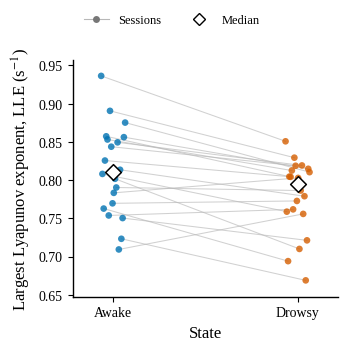

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/lle/lle_state_60s_processed.pdf, .svg, and .png


In [5]:
# Cell 5 - Plot the session-level Awake-Drowsy LLE comparison
from matplotlib.lines import Line2D

STATE_COLORS = {"Awake": "#0072B2", "Drowsy": "#D55E00"}
SESSION_LINE_COLOR = "#B8B8B8"
x_positions = np.arange(len(STATES), dtype=float)
offsets = np.linspace(-0.065, 0.065, len(lle_session_pairs))
paired_lle = lle_session_pairs[["lle_awake", "lle_drowsy"]].to_numpy()

fig, ax = plt.subplots(figsize=(3.54, 3.54))
for offset, values in zip(offsets, paired_lle):
    x_values = x_positions + offset
    ax.plot(
        x_values,
        values,
        color=SESSION_LINE_COLOR,
        alpha=0.65,
        linewidth=0.75,
        zorder=1,
    )
    for x_value, value, state in zip(x_values, values, STATES):
        ax.scatter(
            x_value,
            value,
            s=23,
            color=STATE_COLORS[state],
            alpha=0.80,
            edgecolors="none",
            zorder=2,
        )
ax.scatter(
    x_positions,
    np.median(paired_lle, axis=0),
    s=64,
    marker="D",
    facecolors="white",
    edgecolors="black",
    linewidths=1.1,
    zorder=4,
)
data_min = float(np.min(paired_lle))
data_max = float(np.max(paired_lle))
data_span = max(data_max - data_min, 0.05)
ax.set_ylim(data_min - 0.08 * data_span, data_max + 0.08 * data_span)
ax.set_xlim(-0.22, 1.22)
ax.set_xticks(x_positions, STATES)
ax.set_xlabel("State")
ax.set_ylabel("Largest Lyapunov exponent, LLE (s$^{-1}$)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)

legend_handles = (
    Line2D(
        [0],
        [0],
        color=SESSION_LINE_COLOR,
        marker="o",
        markerfacecolor="#777777",
        markeredgecolor="none",
        linewidth=0.8,
        markersize=5,
        label="Sessions",
    ),
    Line2D(
        [0],
        [0],
        color="none",
        marker="D",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=6,
        label="Median",
    ),
)
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00),
    frameon=False,
    ncol=2,
)
fig.subplots_adjust(left=0.22, right=0.97, bottom=0.17, top=0.84)
state_figure_stem = OUTPUT_DIR / "lle_state_60s_processed"
fig.savefig(state_figure_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(state_figure_stem.with_suffix(".svg"), bbox_inches="tight")
fig.savefig(
    state_figure_stem.with_suffix(".png"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()
print(f"Saved: {state_figure_stem}.pdf, .svg, and .png")


In [6]:
# Cell 6 - Run paired session-level LLE inference
from scipy.stats import rankdata, wilcoxon

BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20_260_829


def bootstrap_median_ci(
    differences: np.ndarray,
    rng: np.random.Generator,
    n_resamples: int,
) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the median."""
    samples = rng.choice(
        differences,
        size=(n_resamples, len(differences)),
        replace=True,
    )
    bootstrap_medians = np.median(samples, axis=1)
    lower, upper = np.percentile(bootstrap_medians, [2.5, 97.5])
    return float(lower), float(upper)


def matched_pairs_rank_biserial(differences: np.ndarray) -> float:
    """Compute signed matched-pairs rank-biserial correlation."""
    nonzero = differences != 0.0
    if not nonzero.any():
        return 0.0
    signed_differences = differences[nonzero]
    ranks = rankdata(np.abs(signed_differences), method="average")
    positive_sum = ranks[signed_differences > 0.0].sum()
    negative_sum = ranks[signed_differences < 0.0].sum()
    return float((positive_sum - negative_sum) / ranks.sum())


def infer_lle_pairs(
    paired: pd.DataFrame,
    bootstrap_seed: int,
) -> tuple[dict, pd.DataFrame]:
    """Run paired inference on session-level LLE summaries."""
    inference_pairs = paired.copy()
    awake = inference_pairs["lle_awake"].to_numpy(dtype=float)
    drowsy = inference_pairs["lle_drowsy"].to_numpy(dtype=float)
    differences = drowsy - awake
    differences[np.isclose(differences, 0.0, rtol=1e-9, atol=1e-12)] = 0.0
    inference_pairs["delta_lle_drowsy_minus_awake"] = differences

    rng = np.random.default_rng(bootstrap_seed)
    ci_low, ci_high = bootstrap_median_ci(
        differences, rng, BOOTSTRAP_RESAMPLES
    )
    if np.any(differences != 0.0):
        wilcoxon_result = wilcoxon(
            differences,
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            method="auto",
        )
        wilcoxon_statistic = float(wilcoxon_result.statistic)
        raw_p_value = float(wilcoxon_result.pvalue)
    else:
        wilcoxon_statistic = 0.0
        raw_p_value = 1.0
    n_positive = int(np.sum(differences > 0.0))
    n_negative = int(np.sum(differences < 0.0))
    n_zero = int(np.sum(differences == 0.0))
    result = {
        "metric": "LLE",
        "n_sessions": len(paired),
        "awake_median": float(np.median(awake)),
        "drowsy_median": float(np.median(drowsy)),
        "median_delta": float(np.median(differences)),
        "bootstrap_ci_low": ci_low,
        "bootstrap_ci_high": ci_high,
        "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
        "bootstrap_seed": bootstrap_seed,
        "wilcoxon_statistic": wilcoxon_statistic,
        "raw_p_value": raw_p_value,
        "rank_biserial_r_rb": matched_pairs_rank_biserial(differences),
        "n_positive": n_positive,
        "n_negative": n_negative,
        "n_zero": n_zero,
    }
    require(
        n_positive + n_negative + n_zero == len(paired),
        "Direction counts must sum to the paired session count.",
    )
    return result, inference_pairs


primary_result, primary_paired_deltas = infer_lle_pairs(
    lle_session_pairs, BOOTSTRAP_SEED
)
primary_result["n_valid_windows"] = len(valid_windows)
lle_state_comparison = pd.DataFrame([primary_result])
comparison_path = OUTPUT_DIR / "lle_state_comparison_60s_processed.csv"
paired_delta_path = (
    OUTPUT_DIR / "lle_session_paired_deltas_60s_processed.csv"
)
lle_state_comparison.to_csv(
    comparison_path, index=False, float_format="%.10g"
)
primary_paired_deltas.to_csv(
    paired_delta_path, index=False, float_format="%.10g"
)
print(
    lle_state_comparison.to_string(
        index=False, float_format=lambda value: f"{value:.5g}"
    )
)
print(f"\nSaved: {comparison_path}")
print(f"Saved: {paired_delta_path}")
print("Raw p-value retained; BH-FDR was not applied.")


metric  n_sessions  awake_median  drowsy_median  median_delta  bootstrap_ci_low  bootstrap_ci_high  bootstrap_resamples  bootstrap_seed  wilcoxon_statistic  raw_p_value  rank_biserial_r_rb  n_positive  n_negative  n_zero  n_valid_windows
   LLE          20       0.81091        0.79472      -0.03757         -0.053698          -0.022976                20000        20260829                  20   0.00070763            -0.80952           4          16       0              872

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/lle/lle_state_comparison_60s_processed.csv
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/lle/lle_session_paired_deltas_60s_processed.csv
Raw p-value retained; BH-FDR was not applied.


In [7]:
# Cell 7 - Evaluate stricter fit-R2 sensitivity
strict_mask = (
    lle_scope["base_qc_eligible"]
    & lle_scope["fit_r2"].ge(SENSITIVITY_R2_THRESHOLD)
)
strict_windows = lle_scope.loc[strict_mask].copy()
strict_state_summary = aggregate_session_states(strict_windows)
strict_session_pairs = construct_pair_table(strict_state_summary)
strict_result, _ = infer_lle_pairs(strict_session_pairs, BOOTSTRAP_SEED)
strict_result["n_valid_windows"] = len(strict_windows)

sensitivity_rows = []
for criterion, threshold, result in (
    ("Primary", PRIMARY_R2_THRESHOLD, primary_result),
    ("Sensitivity", SENSITIVITY_R2_THRESHOLD, strict_result),
):
    sensitivity_rows.append(
        {
            "criterion": criterion,
            "fit_r2_threshold": threshold,
            "retained_windows": result["n_valid_windows"],
            "retained_paired_sessions": result["n_sessions"],
            "median_delta": result["median_delta"],
            "bootstrap_ci_low": result["bootstrap_ci_low"],
            "bootstrap_ci_high": result["bootstrap_ci_high"],
            "raw_p_value": result["raw_p_value"],
            "rank_biserial_r_rb": result["rank_biserial_r_rb"],
            "n_positive": result["n_positive"],
            "n_negative": result["n_negative"],
            "n_zero": result["n_zero"],
        }
    )
lle_qc_sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_path = OUTPUT_DIR / "lle_qc_sensitivity_60s_processed.csv"
lle_qc_sensitivity.to_csv(
    sensitivity_path, index=False, float_format="%.10g"
)
summary_display = lle_qc_sensitivity.copy()
summary_display["bootstrap_95_ci"] = summary_display.apply(
    lambda row: (
        f"[{row['bootstrap_ci_low']:.4f}, "
        f"{row['bootstrap_ci_high']:.4f}]"
    ),
    axis=1,
)
summary_display["positive/negative/zero"] = summary_display.apply(
    lambda row: (
        f"{int(row['n_positive'])}/"
        f"{int(row['n_negative'])}/{int(row['n_zero'])}"
    ),
    axis=1,
)
display_columns = [
    "criterion",
    "fit_r2_threshold",
    "retained_windows",
    "retained_paired_sessions",
    "median_delta",
    "bootstrap_95_ci",
    "raw_p_value",
    "rank_biserial_r_rb",
    "positive/negative/zero",
]
print(
    summary_display[display_columns].to_string(
        index=False, float_format=lambda value: f"{value:.4f}"
    )
)
print(f"\nSaved: {sensitivity_path}")
print(
    "The primary R2 >= 0.90 result remains the main analysis. "
    "The R2 >= 0.95 result is QC sensitivity only; no BH-FDR was applied."
)


  criterion  fit_r2_threshold  retained_windows  retained_paired_sessions  median_delta    bootstrap_95_ci  raw_p_value  rank_biserial_r_rb positive/negative/zero
    Primary            0.9000               872                        20       -0.0376 [-0.0537, -0.0230]       0.0007             -0.8095                 4/16/0
Sensitivity            0.9500               734                        20       -0.0306 [-0.0417, -0.0140]       0.0023             -0.7429                 4/16/0

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/lle/lle_qc_sensitivity_60s_processed.csv
The primary R2 >= 0.90 result remains the main analysis. The R2 >= 0.95 result is QC sensitivity only; no BH-FDR was applied.


### Rosenstein LLE — 60-s Processed PPG

- LLE giảm rõ từ Awake sang Drowsy ở cấp session.
- Primary analysis cho median paired
  \(\Delta = -0.0376\,s^{-1}\),
  với bootstrap 95% CI \([-0.0537,-0.0230]\).
- 16/20 session cho LLE thấp hơn trong Drowsy.
- Paired effect lớn theo rank-biserial
  (\(r_{rb}=-0.8095\)).
- Khi siết QC từ \(R^2\ge0.90\) lên \(R^2\ge0.95\),
  direction và magnitude vẫn được bảo toàn.

**Diễn giải:**  
Drowsiness liên quan đến **giảm local trajectory divergence** trong reconstructed Processed PPG dynamics.

**QC conclusion:**  
Finding không bị chi phối bởi các window có Rosenstein linear fit yếu.

**Claim boundary:**  
LLE giảm không được diễn giải là bằng chứng rằng hệ trở nên “less chaotic” theo nghĩa tuyệt đối hay rằng PPG trải qua một chaos transition.